## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

## 2. Data Loading and Preprocessing

`Processor` loads the train/val/test splits and pre-computes popularity-based sampling weights for negative sampling.

- **`td` / `vd` / `ted`**: `TensorDataset` of `(user_idx, pos_item_idx)` for each split, stored on GPU.
- **`item_sampling_weights`**: per-item weight = `count^0.75` (power-law smoothing). Used in popularity-based and hybrid negative sampling.
- **`sample_negative_random`**: draws `num_negatives` negatives per training example using the popularity weights, then re-samples any collision with the positive item.

In [3]:
class Processor:
    def __init__(self):
        ratingdf = pd.read_csv("/content/drive/MyDrive/proj/data/interactions_clean.csv")
        traindf  = pd.read_csv("/content/drive/MyDrive/proj/data/train_triplets.csv")
        valdf    = pd.read_csv("/content/drive/MyDrive/proj/data/val.csv")
        testdf   = pd.read_csv("/content/drive/MyDrive/proj/data/test.csv")

        self.device  = torch.device('cuda')
        self.n_item  = ratingdf["item_idx"].nunique()
        self.n_user  = traindf["user_idx"].nunique()
        self.n_train = len(traindf)

        trainuser = torch.tensor(traindf["user_idx"].values).to(self.device)
        trainpos  = torch.tensor(traindf["pos_idx"].values).to(self.device)
        self.td   = TensorDataset(trainuser, trainpos)

        valuser = torch.tensor(valdf["user_idx"].values).to(self.device)
        valpos  = torch.tensor(valdf["pos_idx"].values).to(self.device)
        self.vd = TensorDataset(valuser, valpos)

        testuser = torch.tensor(testdf["user_idx"].values).to(self.device)
        testpos  = torch.tensor(testdf["pos_idx"].values).to(self.device)
        self.ted = TensorDataset(testuser, testpos)

        # Popularity weights: count^0.75 (power-law smoothing)
        item_counts = traindf['pos_idx'].value_counts().reindex(range(self.n_item), fill_value=0)
        weights = (item_counts + 1e-6) ** 0.75
        self.item_sampling_weights = torch.tensor(weights.values, dtype=torch.float, device=self.device)

    def sample_negative_random(self, pos_idxs, batch_size=512, num_negatives=5):
        """Sample popularity-weighted negatives, re-sampling any collision with the positive."""
        negs = torch.multinomial(self.item_sampling_weights,
                                 num_samples=batch_size * num_negatives,
                                 replacement=True).view(batch_size, num_negatives)
        while torch.any(negs == pos_idxs.unsqueeze(1)):
            mask = (negs == pos_idxs.unsqueeze(1))
            rows, cols = mask.nonzero(as_tuple=True)
            negs[rows, cols] = torch.multinomial(self.item_sampling_weights,
                                                 num_samples=rows.size(0),
                                                 replacement=True)
        return negs

## 3. Model Architecture

**Two-Tower model**: separate user and item encoder towers that project IDs into a shared L2-normalised embedding space. Similarity is measured by dot product (= cosine similarity after normalisation).

Each tower is:
- `nn.Embedding` → lookup the raw embedding for the given ID
- Optional 2-layer MLP with residual connections and LayerNorm (enabled when `use_mlp_layers=True`)
- L2 normalisation → unit-norm output vector

**Loss** is computed inside `TwoTowerModel.forward` and depends on `sampling_method`:

| Method | Negatives used | Loss formulation |
|--------|---------------|-----------------|
| `in_batch` | All other positives in the batch | InfoNCE / NT-Xent: softmax cross-entropy over the full batch similarity matrix |
| `popularity_based` | Pre-sampled popularity-weighted negatives | Softmax cross-entropy: positive score vs. `num_negatives` negative scores |
| `hybrid_negative_sampling` | Both: in-batch negatives + popularity negatives | Combined logit row: `[pos | in-batch negs | popularity negs]`, cross-entropy with label 0 |

Temperature `τ` scales all logits before softmax, controlling the sharpness of the distribution.

In [4]:
class UserEmbeddingModel(nn.Module):
    def __init__(self, user_n, d_model, use_mlp_layers=False, dropout_rate=0.0):
        super().__init__()
        self.model = nn.Embedding(user_n, d_model)
        self.use_mlp_layers = use_mlp_layers
        self.dropout = nn.Dropout(dropout_rate)
        if self.use_mlp_layers:
            self.l1 = nn.Linear(d_model, d_model)
            self.l2 = nn.Linear(d_model, d_model)
            self.n1 = nn.LayerNorm(d_model)
            self.n2 = nn.LayerNorm(d_model)

    def forward(self, user_idxs):
        x = self.model(user_idxs)
        if self.use_mlp_layers:
            x = self.n1(x + F.relu(self.l1(x)))
            x = self.n2(x + F.relu(self.l2(x)))
        return F.normalize(x, p=2, dim=1)


class ItemEmbeddingModel(nn.Module):
    def __init__(self, n_item, d_model, use_mlp_layers=False, dropout_rate=0.0):
        super().__init__()
        self.model = nn.Embedding(n_item, d_model)
        self.use_mlp_layers = use_mlp_layers
        self.dropout = nn.Dropout(dropout_rate)
        if self.use_mlp_layers:
            self.l1 = nn.Linear(d_model, d_model)
            self.l2 = nn.Linear(d_model, d_model)
            self.n1 = nn.LayerNorm(d_model)
            self.n2 = nn.LayerNorm(d_model)

    def forward(self, item_idxs):
        x = self.model(item_idxs)
        if self.use_mlp_layers:
            x = self.n1(x + F.relu(self.l1(x)))
            x = self.n2(x + F.relu(self.l2(x)))
        return F.normalize(x, p=2, dim=1)


class TwoTowerModel(nn.Module):
    def __init__(self, n_user, n_item, d_model,
                 use_mlp_layers=False, sampling_method='in_batch',
                 temperature=1.0, dropout_rate=0.0):
        super().__init__()
        self.usermodel       = UserEmbeddingModel(n_user, d_model, use_mlp_layers, dropout_rate)
        self.itemmodel       = ItemEmbeddingModel(n_item, d_model, use_mlp_layers, dropout_rate)
        self.sampling_method = sampling_method
        self.temperature     = temperature

    def forward(self, user_idx, pos_idx, neg_idxs=None):
        user_vec = self.usermodel(user_idx)

        if self.sampling_method == 'in_batch':
            # Each user treats all other batch positives as negatives
            scores = (user_vec @ self.itemmodel(pos_idx).T) / self.temperature
            labels = torch.arange(scores.shape[0], dtype=torch.long, device=scores.device)
            return F.cross_entropy(scores, labels)

        elif self.sampling_method == 'popularity_based':
            pos_vec  = self.itemmodel(pos_idx).unsqueeze(1)        # (B, 1, d)
            neg_vecs = self.itemmodel(neg_idxs)                    # (B, n_neg, d)
            u        = user_vec.unsqueeze(1)                       # (B, 1, d)
            logits   = torch.cat([(u * pos_vec).sum(2),
                                  (u * neg_vecs).sum(2)], dim=1) / self.temperature  # (B, 1+n_neg)
            labels   = torch.zeros(logits.shape[0], dtype=torch.long, device=logits.device)
            return F.cross_entropy(logits, labels)

        elif self.sampling_method == 'hybrid_negative_sampling':
            pos_vec  = self.itemmodel(pos_idx)                     # (B, d)
            neg_vecs = self.itemmodel(neg_idxs)                    # (B, n_neg, d)
            B        = user_idx.shape[0]

            # In-batch scores: full (B x B) matrix, diagonal = positive
            in_batch_scores  = user_vec @ pos_vec.T                # (B, B)
            pos_scores       = torch.diag(in_batch_scores).unsqueeze(1)  # (B, 1)
            mask             = ~torch.eye(B, dtype=torch.bool, device=user_vec.device)
            in_batch_neg_scores = in_batch_scores[mask].view(B, B - 1)  # (B, B-1)

            # Popularity-sampled negative scores
            pop_neg_scores = (user_vec.unsqueeze(1) * neg_vecs).sum(2)  # (B, n_neg)

            # Combine: [pos | in-batch negs | popularity negs], label = 0
            logits = torch.cat([pos_scores, in_batch_neg_scores, pop_neg_scores], dim=1) / self.temperature
            labels = torch.zeros(B, dtype=torch.long, device=logits.device)
            return F.cross_entropy(logits, labels)

        else:
            raise ValueError(f"Unknown sampling_method: {self.sampling_method}")

## 4. Evaluation Metrics

Helper functions used during training (full-ranking evaluation against all 81k items):

- **NDCG@k**: rewards hits ranked higher in the list. For a single relevant item at rank `r`, NDCG = 1/log₂(r+1).
- **MRR**: Mean Reciprocal Rank = average of 1/rank across all users (no cutoff in this formulation).

In [5]:
def dcg_at_k(r, k):
    r = np.asarray(r, dtype=np.float64)[:k]
    if r.size:
        return r[0] + np.sum(r[1:] / np.log2(np.arange(2, r.size + 1)))
    return 0.0

def ndcg_at_k(r, k):
    dcg_max = dcg_at_k(sorted(r, reverse=True), k)
    if not dcg_max:
        return 0.0
    return dcg_at_k(r, k) / dcg_max

def mrr_at_k(rank, k):
    """Reciprocal rank contribution for one user; 0 if rank > k."""
    return 1.0 / rank if rank <= k else 0.0

## 5. Training Configuration

Key hyperparameters and their roles:

| Parameter | Value | Purpose |
|-----------|-------|---------|
| `d_model` | 128 | Embedding dimensionality for both towers |
| `batch_size` | 512 | Batch size; also determines in-batch negative count |
| `sampling_method` | `hybrid_negative_sampling` | Combines in-batch and popularity-weighted negatives |
| `temperature` | 0.3 | Softmax temperature τ: lower = sharper distribution, harder training signal |
| `n_neg_sample_popularity` | 5 | Number of popularity-weighted negatives per example |
| `lr` | 0.05 | Initial learning rate (decayed by CosineAnnealingLR) |
| `use_mlp_layers` | False | Whether to add the 2-layer residual MLP on top of embeddings |
| `patient` | 5 | Early stopping patience on val Recall@10 |

In [6]:
CONFIG = {
    "epoch_size":               200,
    "d_model":                  128,
    "batch_size":               512,
    "use_mlp_layers":           False,
    "sampling_method":          "hybrid_negative_sampling",
    "temperature":              0.3,
    "lr":                       0.05,
    "dropout_rate":             0.3,
    "n_neg_sample_popularity":  5,
    "patient":                  5,
}

## 6. Model Initialisation

Instantiate the `Processor`, model, optimiser, and learning-rate scheduler.  
`CosineAnnealingLR` decays the learning rate from `lr` to `eta_min=1e-4` over `epoch_size` steps.

The 100-candidate validation tensors (`val.csv` + `val_negatives.csv`) are also pre-loaded here so they can be reused each epoch without repeated file I/O.

In [8]:
device    = torch.device('cuda')
processor = Processor()
train, val, test = processor.td, processor.vd, processor.ted

train_loader = DataLoader(train, shuffle=True, batch_size=CONFIG["batch_size"])

twotower_model = TwoTowerModel(
    processor.n_user,
    processor.n_item,
    CONFIG["d_model"],
    use_mlp_layers   = CONFIG["use_mlp_layers"],
    sampling_method  = CONFIG["sampling_method"],
    temperature      = CONFIG["temperature"],
    dropout_rate     = CONFIG["dropout_rate"],
).to(device)

optimizer = Adam(twotower_model.parameters(), lr=CONFIG["lr"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG["epoch_size"], eta_min=1e-4
)

# ── Pre-load 100-candidate validation set (used every epoch) ──────────────────
_val_df     = pd.read_csv("/content/drive/MyDrive/proj/data/val.csv").sort_values("user_idx").reset_index(drop=True)
_val_neg_df = pd.read_csv("/content/drive/MyDrive/proj/data/val_negatives.csv").sort_values("user_idx").reset_index(drop=True)

_user_ids_np  = _val_df["user_idx"].values
_pos_items_np = _val_df["pos_idx"].values
_neg_items_np = np.stack(_val_neg_df["neg_items"].apply(lambda x: [int(i) for i in x.split()]).values)

# candidates_val[i] = [positive, neg_0, ..., neg_99]  →  (n_val, 101)
candidates_val = np.concatenate([_pos_items_np[:, None], _neg_items_np], axis=1)
candidates_val_t = torch.tensor(candidates_val, dtype=torch.long, device=device)
val_user_ids_t   = torch.tensor(_user_ids_np,   dtype=torch.long, device=device)

print(f"Items: {processor.n_item}  |  Users: {processor.n_user}")
print(f"Val candidates tensor: {candidates_val_t.shape}")

Items: 81322  |  Users: 64867
Val candidates tensor: torch.Size([64867, 101])


## 7. Training Loop with 100-Candidate Validation

Each epoch:
1. **Train** — iterate over shuffled batches; compute loss and update weights.
2. **Validate** — for each validation user, score their 101 candidates (1 positive + 100 pre-sampled negatives) and find the rank of the positive. This is ~800× faster than full-ranking evaluation over all 81k items.
3. **Early stopping** — stop if val Recall@10 does not improve for `patient` epochs.
4. **Save** — save model weights whenever a new best Recall@10 is found.

In [9]:
# Validation DataLoader for batched 100-candidate scoring
val_cand_loader = DataLoader(
    TensorDataset(val_user_ids_t, candidates_val_t),
    batch_size=CONFIG["batch_size"], shuffle=False
)
k = 10

losses_per_epoch = []
recall_epochs    = []
precision_epochs = []
ndcg_epochs      = []
mrr_epochs       = []

best_recall    = 0.0
patience_count = 0

for epoch in range(CONFIG["epoch_size"]):
    print(f"epoch_{epoch}")

    # ── Training ──────────────────────────────────────────────────────────────
    twotower_model.train()
    batch_losses = []

    for user_idx, pos_idx in train_loader:
        if CONFIG["sampling_method"] == 'in_batch':
            loss = twotower_model(user_idx, pos_idx)
        else:
            neg_idx = processor.sample_negative_random(
                pos_idx, batch_size=len(user_idx),
                num_negatives=CONFIG["n_neg_sample_popularity"])
            loss = twotower_model(user_idx, pos_idx, neg_idxs=neg_idx)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    losses_per_epoch.append(np.mean(batch_losses))

    # ── 100-Candidate Validation ──────────────────────────────────────────────
    twotower_model.eval()
    ranks_epoch = []

    with torch.no_grad():
        for bu, bc in val_cand_loader:
            # bu: (B,)  bc: (B, 101) — first column is the positive
            u_vecs = twotower_model.usermodel(bu)                              # (B, d)
            c_vecs = twotower_model.itemmodel(bc.view(-1)).view(len(bu), 101, -1)  # (B, 101, d)
            scores = torch.bmm(u_vecs.unsqueeze(1), c_vecs.transpose(1, 2)).squeeze(1)  # (B, 101)

            # Rank of the positive (index 0) for each user in the batch
            order = torch.argsort(scores, dim=1, descending=True)             # (B, 101)
            pos_ranks = (order == 0).nonzero(as_tuple=True)[1] + 1            # 1-indexed
            ranks_epoch.extend(pos_ranks.cpu().tolist())

    ranks_arr = np.array(ranks_epoch)
    hits       = ranks_arr <= k

    recall_val    = hits.mean()
    precision_val = recall_val / k
    ndcg_val      = np.where(hits, 1.0 / np.log2(ranks_arr + 1), 0.0).mean()
    mrr_val       = (1.0 / ranks_arr).mean()

    recall_epochs.append(recall_val)
    precision_epochs.append(precision_val)
    ndcg_epochs.append(ndcg_val)
    mrr_epochs.append(mrr_val)

    print(f"  Loss: {losses_per_epoch[-1]:.4f}  "
          f"Recall@{k}: {recall_val:.4f}  "
          f"NDCG@{k}: {ndcg_val:.4f}  "
          f"MRR: {mrr_val:.4f}")

    # ── Early Stopping & Checkpointing ───────────────────────────────────────
    if recall_val > best_recall:
        best_recall    = recall_val
        patience_count = 0
        torch.save(twotower_model.state_dict(), 'best_model.pth')
        print(f"  >> New best Recall@{k}: {best_recall:.4f} — model saved.")
    else:
        patience_count += 1
        if patience_count > CONFIG["patient"]:
            print(f"  >> Early stopping at epoch {epoch + 1}.")
            break

    scheduler.step()

epoch_0
  Loss: 6.1459  Recall@10: 0.4107  NDCG@10: 0.2698  MRR: 0.2461
  >> New best Recall@10: 0.4107 — model saved.
epoch_1
  Loss: 5.1159  Recall@10: 0.6797  NDCG@10: 0.4862  MRR: 0.4391
  >> New best Recall@10: 0.6797 — model saved.
epoch_2
  Loss: 4.8251  Recall@10: 0.7461  NDCG@10: 0.5444  MRR: 0.4926
  >> New best Recall@10: 0.7461 — model saved.
epoch_3
  Loss: 4.7071  Recall@10: 0.7728  NDCG@10: 0.5692  MRR: 0.5156
  >> New best Recall@10: 0.7728 — model saved.
epoch_4
  Loss: 4.6354  Recall@10: 0.7870  NDCG@10: 0.5817  MRR: 0.5269
  >> New best Recall@10: 0.7870 — model saved.
epoch_5
  Loss: 4.5832  Recall@10: 0.7954  NDCG@10: 0.5899  MRR: 0.5345
  >> New best Recall@10: 0.7954 — model saved.
epoch_6
  Loss: 4.5443  Recall@10: 0.8016  NDCG@10: 0.5960  MRR: 0.5405
  >> New best Recall@10: 0.8016 — model saved.
epoch_7
  Loss: 4.5116  Recall@10: 0.8042  NDCG@10: 0.5993  MRR: 0.5438
  >> New best Recall@10: 0.8042 — model saved.
epoch_8
  Loss: 4.4841  Recall@10: 0.8084  NDCG@

## 8. Training Curves

Plot loss and validation metrics over epochs to inspect convergence and overfitting.

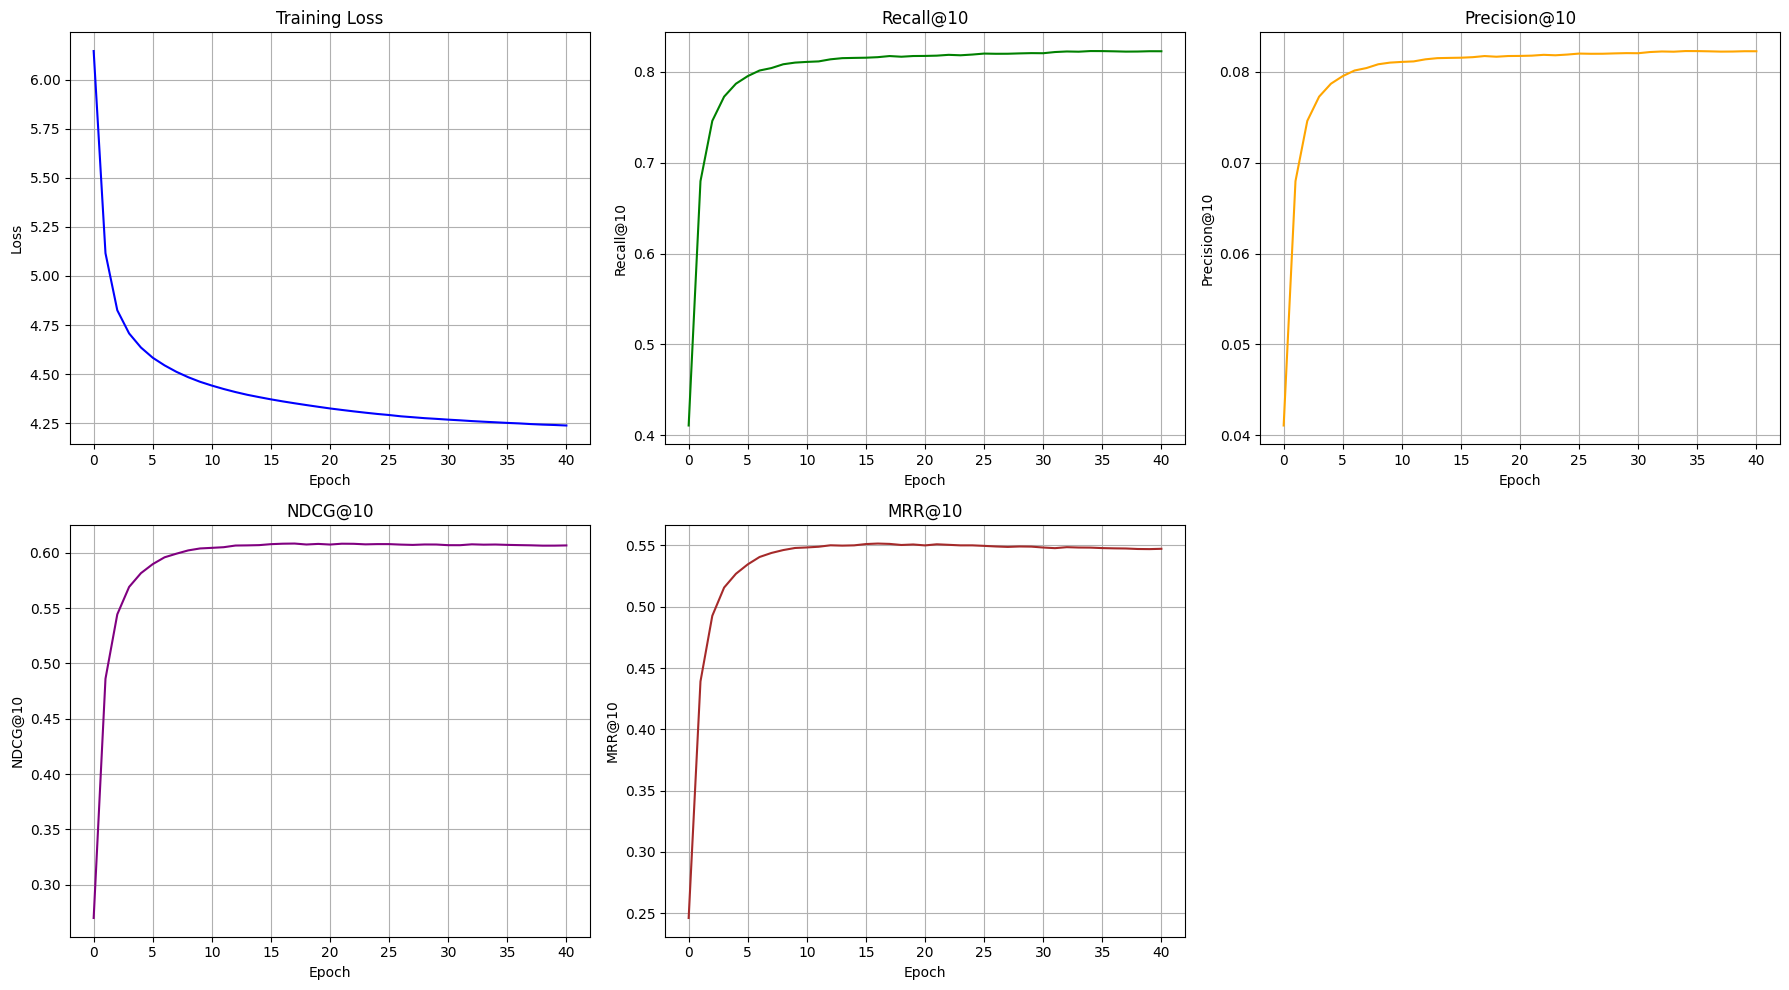

Best epoch: 35
  Recall@10:    0.8230
  Precision@10: 0.0823
  NDCG@10:      0.6076
  MRR@10:       0.5482


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = [
    (losses_per_epoch,   "Training Loss",          "Loss",          "blue"),
    (recall_epochs,      f"Recall@{k}",            f"Recall@{k}",   "green"),
    (precision_epochs,   f"Precision@{k}",         f"Precision@{k}","orange"),
    (ndcg_epochs,        f"NDCG@{k}",              f"NDCG@{k}",     "purple"),
    (mrr_epochs,         f"MRR@{k}",               f"MRR@{k}",      "brown"),
]

for ax, (data, title, ylabel, color) in zip(axes.flat, metrics):
    ax.plot(data, color=color)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True)

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

# Best epoch summary
best_epoch = recall_epochs.index(max(recall_epochs))
print(f"Best epoch: {best_epoch + 1}")
print(f"  Recall@{k}:    {recall_epochs[best_epoch]:.4f}")
print(f"  Precision@{k}: {precision_epochs[best_epoch]:.4f}")
print(f"  NDCG@{k}:      {ndcg_epochs[best_epoch]:.4f}")
print(f"  MRR@{k}:       {mrr_epochs[best_epoch]:.4f}")

## 9. Ablation Study: Sampling Strategy Comparison

We compare five configurations that isolate the effect of each design choice.  
All experiments use the same **100-candidate validation protocol** (1 positive + 100 pre-sampled negatives = 101 candidates per user), consistent with the full evaluation in Section 10.

| Experiment | Sampling Method | MLP | Temperature |
|------------|----------------|-----|-------------|
| In-Batch (baseline) | `in_batch` | No | 0.5 |
| Popularity-Based | `popularity_based` | No | 0.5 |
| Hybrid | `hybrid_negative_sampling` | No | 0.5 |
| Hybrid + lower τ | `hybrid_negative_sampling` | No | 0.3 |
| Hybrid + MLP | `hybrid_negative_sampling` | Yes | 0.5 |

In [17]:
# ── Ablation Study: Sampling Strategy Comparison ────────────────────────────

ABLATION_CONFIGS = [
    {"name": "In-Batch (baseline)",   "sampling_method": "in_batch",               "use_mlp_layers": False, "temperature": 0.5},
    {"name": "Popularity-Based",      "sampling_method": "popularity_based",        "use_mlp_layers": False, "temperature": 0.5},
    {"name": "Hybrid",                "sampling_method": "hybrid_negative_sampling","use_mlp_layers": False, "temperature": 0.5},
    {"name": "Hybrid + low τ=0.3",    "sampling_method": "hybrid_negative_sampling","use_mlp_layers": False, "temperature": 0.3},
    {"name": "Hybrid + MLP",          "sampling_method": "hybrid_negative_sampling","use_mlp_layers": True,  "temperature": 0.5},
]

SHARED = {
    "epoch_size": 200,
    "d_model": 128,
    "batch_size": 512,
    "lr": 0.05,
    "dropout_rate": 0.3,
    "n_neg_sample_popularity": 5,
    "patient": 5,
}

k = 10
ablation_results = []

# Reuse the pre-loaded 100-candidate tensors from Section 6
abl_val_loader = DataLoader(
    TensorDataset(val_user_ids_t, candidates_val_t),
    batch_size=SHARED["batch_size"], shuffle=False
)

global_best_ablation_recall = 0.0
global_best_ablation_model_state = None

for cfg in ABLATION_CONFIGS:
    print(f"\n{'='*60}")
    print(f"Running: {cfg['name']}")
    print(f"{'='*60}")

    model = TwoTowerModel(
        processor.n_user, processor.n_item, SHARED["d_model"],
        use_mlp_layers  = cfg["use_mlp_layers"],
        sampling_method = cfg["sampling_method"],
        temperature     = cfg["temperature"],
        dropout_rate    = SHARED["dropout_rate"],
    ).to(device)

    opt   = Adam(model.parameters(), lr=SHARED["lr"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=SHARED["epoch_size"], eta_min=1e-4)
    loader = DataLoader(train, shuffle=True, batch_size=SHARED["batch_size"])

    best_recall_cfg = 0.0
    best_metrics    = {}
    patience_count  = 0
    current_config_best_model_state = None # To store the best model state for the current config

    for epoch in range(SHARED["epoch_size"]):

        # ── Train ──────────────────────────────────────────────────────────────
        model.train()
        for user_idx, pos_idx in loader:
            if cfg["sampling_method"] == "in_batch":
                loss = model(user_idx, pos_idx)
            else:
                neg_idx = processor.sample_negative_random(
                    pos_idx, batch_size=len(user_idx),
                    num_negatives=SHARED["n_neg_sample_popularity"])
                loss = model(user_idx, pos_idx, neg_idxs=neg_idx)
            opt.zero_grad()
            loss.backward()
            opt.step()

        # ── 100-Candidate Validation ───────────────────────────────────────────
        model.eval()
        ranks_epoch = []

        with torch.no_grad():
            for bu, bc in abl_val_loader:
                u_vecs = model.usermodel(bu)                                        # (B, d)
                c_vecs = model.itemmodel(bc.view(-1)).view(len(bu), 101, -1)        # (B, 101, d)
                scores = torch.bmm(u_vecs.unsqueeze(1), c_vecs.transpose(1, 2)).squeeze(1)  # (B, 101)
                order  = torch.argsort(scores, dim=1, descending=True)
                pos_ranks = (order == 0).nonzero(as_tuple=True)[1] + 1
                ranks_epoch.extend(pos_ranks.cpu().tolist())

        ranks_arr  = np.array(ranks_epoch)
        hits       = ranks_arr <= k
        recall_val = hits.mean()
        ndcg_val   = np.where(hits, 1.0 / np.log2(ranks_arr + 1), 0.0).mean()
        mrr_val    = (1.0 / ranks_arr).mean()

        print(f"  Epoch {epoch+1:3d}  Recall@{k}: {recall_val:.4f}  NDCG@{k}: {ndcg_val:.4f}  MRR: {mrr_val:.4f}")

        # ── Early Stopping & Checkpointing for current config─────────────────────────────────────
        if recall_val > best_recall_cfg:
            best_recall_cfg = recall_val
            best_metrics    = {"Recall@10": recall_val, "NDCG@10": ndcg_val, "MRR": mrr_val, "Best Epoch": epoch + 1}
            patience_count  = 0
            current_config_best_model_state = model.state_dict() # Save state dict of the best model for this config
        else:
            patience_count += 1
            if patience_count > SHARED["patient"]:
                print(f"  >> Early stopping at epoch {epoch + 1}.")
                break

        sched.step()

    # Update global best model if current config's best is better
    if best_recall_cfg > global_best_ablation_recall:
        global_best_ablation_recall = best_recall_cfg
        global_best_ablation_model_state = current_config_best_model_state

    ablation_results.append({"Model": cfg["name"],
                              "Sampling": cfg["sampling_method"],
                              "MLP": cfg["use_mlp_layers"],
                              "τ": cfg["temperature"],
                              **best_metrics})

# Save the globally best model after the ablation study
if global_best_ablation_model_state is not None:
    torch.save(global_best_ablation_model_state, 'best_model.pth')
    print(f"\nSaved the overall best model from ablation study with Recall@{k}: {global_best_ablation_recall:.4f}")

results_df = pd.DataFrame(ablation_results).sort_values("Recall@10", ascending=False).reset_index(drop=True)
print("\n" + "="*70)
print("Ablation Study Results (100-Candidate Validation, k=10)")
print("="*70)
print(results_df.to_string(index=False))


Running: In-Batch (baseline)
  Epoch   1  Recall@10: 0.4793  NDCG@10: 0.3205  MRR: 0.2898
  Epoch   2  Recall@10: 0.7384  NDCG@10: 0.5279  MRR: 0.4741
  Epoch   3  Recall@10: 0.7802  NDCG@10: 0.5549  MRR: 0.4951
  Epoch   4  Recall@10: 0.7919  NDCG@10: 0.5597  MRR: 0.4974
  Epoch   5  Recall@10: 0.7960  NDCG@10: 0.5601  MRR: 0.4966
  Epoch   6  Recall@10: 0.8000  NDCG@10: 0.5613  MRR: 0.4966
  Epoch   7  Recall@10: 0.8021  NDCG@10: 0.5622  MRR: 0.4971
  Epoch   8  Recall@10: 0.8034  NDCG@10: 0.5627  MRR: 0.4973
  Epoch   9  Recall@10: 0.8051  NDCG@10: 0.5632  MRR: 0.4972
  Epoch  10  Recall@10: 0.8056  NDCG@10: 0.5642  MRR: 0.4984
  Epoch  11  Recall@10: 0.8062  NDCG@10: 0.5645  MRR: 0.4986
  Epoch  12  Recall@10: 0.8078  NDCG@10: 0.5656  MRR: 0.4994
  Epoch  13  Recall@10: 0.8086  NDCG@10: 0.5663  MRR: 0.5000
  Epoch  14  Recall@10: 0.8080  NDCG@10: 0.5666  MRR: 0.5007
  Epoch  15  Recall@10: 0.8096  NDCG@10: 0.5667  MRR: 0.5002
  Epoch  16  Recall@10: 0.8095  NDCG@10: 0.5668  MRR: 0

/tmp/ipykernel_955/3971763460.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df["Model"], rotation=20, ha='right', fontsize=9)
/tmp/ipykernel_955/3971763460.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df["Model"], rotation=20, ha='right', fontsize=9)
/tmp/ipykernel_955/3971763460.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df["Model"], rotation=20, ha='right', fontsize=9)


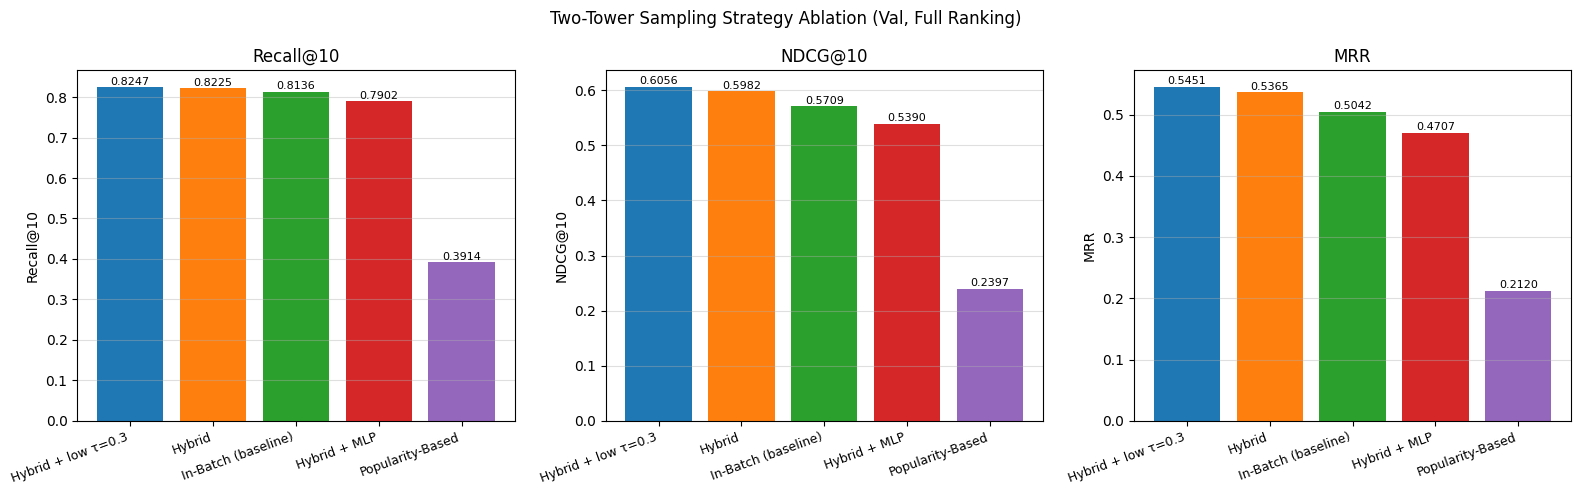

In [18]:
import matplotlib.pyplot as plt
metrics_to_plot = ["Recall@10", "NDCG@10", "MRR"]
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(results_df["Model"], results_df[metric],
                  color=colors[:len(results_df)])
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xticklabels(results_df["Model"], rotation=20, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.4)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f"{val:.4f}", ha='center', va='bottom', fontsize=8)

plt.suptitle("Two-Tower Sampling Strategy Ablation (Val, Full Ranking)", fontsize=12)
plt.tight_layout()
plt.show()

## 10. Best model on testset

Evaluate the saved best model using the standard 100-candidate protocol (shared across all team models)

In [20]:
EVAL_SEED = 2026
K = 10

# Load and sort both files by user_idx to ensure alignment
val_df     = pd.read_csv("/content/drive/MyDrive/proj/data/test.csv").sort_values("user_idx").reset_index(drop=True)
val_neg_df = pd.read_csv("/content/drive/MyDrive/proj/data/test_negatives.csv").sort_values("user_idx").reset_index(drop=True)

user_ids_np  = val_df["user_idx"].values                                  # (n,)
pos_items_np = val_df["pos_idx"].values                                    # (n,)
neg_items_np = np.stack(                                                   # (n, 100)
    val_neg_df["neg_items"].apply(lambda x: [int(i) for i in x.split()]).values
)

# candidates[i] = [positive, neg_0, ..., neg_99]  →  shape (n, 101)
candidates_np = np.concatenate([pos_items_np[:, None], neg_items_np], axis=1)


def rank_from_scores(user, candidates, scores, seed):
    """Rank positive (index 0 in candidates) with seeded tie-breaking shuffle."""
    candidates = np.asarray(candidates, dtype=np.int64)
    scores     = np.asarray(scores,     dtype=np.float64)
    rng        = np.random.default_rng(seed + int(user))
    perm       = rng.permutation(len(candidates))
    shuffled_positive = int(np.flatnonzero(perm == 0)[0])
    order = np.argsort(-scores[perm], kind="stable")
    return int(np.flatnonzero(order == shuffled_positive)[0]) + 1


# Load the best checkpoint saved during training
twotower_model.load_state_dict(torch.load('best_model.pth', map_location=device))
twotower_model.eval()

ranks = []
BATCH = 512

with torch.no_grad():
    for start in range(0, len(user_ids_np), BATCH):
        end  = min(start + BATCH, len(user_ids_np))
        bu   = torch.tensor(user_ids_np[start:end],   dtype=torch.long, device=device)
        bc   = torch.tensor(candidates_np[start:end], dtype=torch.long, device=device)  # (B, 101)

        u_vecs = twotower_model.usermodel(bu)                              # (B, d)
        c_vecs = twotower_model.itemmodel(bc.view(-1)).view(len(bu), 101, -1)  # (B, 101, d)
        scores = torch.bmm(u_vecs.unsqueeze(1), c_vecs.transpose(1, 2)).squeeze(1)  # (B, 101)
        scores_np = scores.cpu().numpy()

        for i, user in enumerate(user_ids_np[start:end]):
            ranks.append(rank_from_scores(user, candidates_np[start + i], scores_np[i], EVAL_SEED))

ranks = np.array(ranks)
hits  = ranks <= K

print(f"=== Two-Tower HNS-TT  |  100-Candidate Evaluation  (k={K}) ===")
print(f"Recall@{K}:    {hits.mean():.4f}")
print(f"Precision@{K}: {hits.mean() / K:.4f}")
print(f"NDCG@{K}:      {np.where(hits, 1.0 / np.log2(ranks + 1), 0.0).mean():.4f}")
print(f"MRR:           {(1.0 / ranks).mean():.4f}")
print(f"Users:         {len(ranks)}")

=== Two-Tower HNS-TT  |  100-Candidate Evaluation  (k=10) ===
Recall@10:    0.7700
Precision@10: 0.0770
NDCG@10:      0.5412
MRR:           0.4801
Users:         64867
